# 06 · RQ3 · ¿Dónde está el cuello de botella? — el experimento de los tres brazos

Producción llega a ~58 % de Edge F1. La pregunta de este notebook es **por qué no llega
más arriba**, y la responde sustituyendo la entrada de Stage 2 por dos oráculos distintos
mientras **todo lo demás queda idéntico**: mismo prompt (sha `ed1d85054d73`), mismo panel
de 30, mismo modelo, temperatura 0, mismo evaluador.

Lo único que cambia es **qué World Model recibe Stage 2**:

| brazo | World Model que entra a Stage 2 | qué mide |
|---|---|---|
| **Producción** | el que genera Stage 1 automáticamente | el sistema tal como corre |
| **A · Oráculo visión** | transcripción **humana** de la pizarra, hecha a ciegas (sin audio, sin ver el GT) | el techo de *leer la pizarra* |
| **B · Oráculo GT** | el ground truth convertido a World Model | el techo de *Stage 2* con la respuesta en la mano |

La lógica del diseño: si el problema fuera que **Stage 1 lee mal la pizarra**, el brazo A
—donde un humano la leyó con cuidado— tendría que acercarse al brazo B. Si en cambio el
brazo A se queda pegado a producción, entonces el problema no es de percepción sino de
**información disponible**: lo que falta no está en la imagen.

> **Adelanto del resultado, porque cambia la conclusión del paper:** el brazo A **no** se
> despega de producción. La diferencia cae dentro del piso de ruido. El cuello de botella
> **no es la fidelidad visual de Stage 1** — es que la pizarra, sola, no contiene la
> topología.

## 1 · Carga de las tres condiciones

Se filtra por **hash de prompt** (`ed1d85054d73`, el de producción) para que ninguna
diferencia sea atribuible al prompt. Las corridas con `connection_evidence` quedan afuera:
cambian la entrada por otra vía.

In [1]:
import json
from math import comb, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ABL  = Path("../reports/ablation")
PISO = Path("../reports/piso_ruido_panel30.json")
PROD_SHA = "ed1d85054d73"

pd.set_option("display.width", 200)

def cargar():
    out = {"produccion": [], "A · vision": [], "B · oracle_gt": []}
    for rj in sorted(ABL.glob("*_p30*/run.json")):
        d = json.loads(rj.read_text(encoding="utf-8"))
        if "stage2_prompt" not in d:
            continue                                  # p.ej. la auditoria de retornos
        if d["stage2_prompt"]["sha256"][:12] != PROD_SHA:
            continue                                  # otro prompt -> otra variable
        if d.get("connection_evidence_enabled"):
            continue                                  # cambia la entrada por otra via
        if not d.get("transcript_enabled", True):
            # La ablacion de transcript comparte prompt y ausencia de oraculo con
            # produccion: sin este filtro entraria como una replica mas y moveria
            # la media del brazo. Es otro experimento (ver notebook aparte).
            continue
        orc = (d.get("oracle") or {}).get("name")
        rama = {"vision": "A · vision", "oracle_gt": "B · oracle_gt"}.get(orc, "produccion")
        out[rama].append({
            "corrida": rj.parent.name,
            "svc": d["metrics"]["service_f1_mean"],
            "edge": d["metrics"]["edge_f1_mean"],
            "por_video": {r["video_id"]: r for r in d["results"] if r["status"] == "success"},
        })
    return out

BRAZOS = cargar()
MDE = {m: v["mde_30"] for m, v in json.loads(PISO.read_text(encoding="utf-8"))["metricas"].items()}

filas = [{"brazo": b, "corrida": c["corrida"][:58], "Service F1": c["svc"], "Edge F1": c["edge"],
          "n_videos": len(c["por_video"])}
         for b, cs in BRAZOS.items() for c in cs]
display(pd.DataFrame(filas).set_index(["brazo", "corrida"]))

print(f"MDE n=30 (de 01_calibracion_ruido): Edge {MDE['Edge F1']:.2f} pts · "
      f"Service {MDE['Service F1']:.2f} pts")

Service F1  Edge F1  n_videos
brazo         corrida                                                                          
produccion    2026-08-25_1637_STAGE2_V6_CORRECTED_cell9_p30            88.07    58.99        30
              2026-08-27_1640_STAGE2_V6_CORRECTED_cell9_p30_rep2       87.03    57.86        30
              2026-08-29_0442_STAGE2_V6_CORRECTED_cell9_p30_rep3       87.19    57.81        30
              2026-08-29_0715_STAGE2_V6_CORRECTED_cell9_p30_rep4       86.13    57.87        30
A · vision    2026-08-29_0725_STAGE2_V6_CORRECTED_cell9_p30_o...       87.82    60.40        30
B · oracle_gt 2026-08-28_0315_STAGE2_V6_CORRECTED_cell9_p30_o...       99.70    83.18        30
              2026-08-28_2211_STAGE2_V6_CORRECTED_cell9_p30_o...       99.44    81.16        30

MDE n=30 (de 01_calibracion_ruido): Edge 3.29 pts · Service 1.76 pts


Producción tiene 4 réplicas y el oráculo GT 2; el brazo A tiene **una sola corrida**.
Es la limitación principal de este notebook y hay que declararla en el paper: una réplica
de A costaría 30 llamadas y cerraría la simetría.

## 2 · El resultado central

Se promedia por brazo y se compara contra el efecto mínimo detectable. Todo lo que no
supere el MDE **no es distinguible de volver a llamar al mismo prompt**.

In [2]:
resumen = []
for b, cs in BRAZOS.items():
    resumen.append({"brazo": b, "corridas": len(cs),
                    "Service F1": np.mean([c["svc"] for c in cs]),
                    "Edge F1": np.mean([c["edge"] for c in cs])})
res = pd.DataFrame(resumen).set_index("brazo")
display(res.round(2))

base = res.loc["produccion", "Edge F1"]
print(f"\nContra produccion (Edge F1 = {base:.2f}, MDE = {MDE['Edge F1']:.2f} pts):\n")
for b in ["A · vision", "B · oracle_gt"]:
    d = res.loc[b, "Edge F1"] - base
    veces = abs(d) / MDE["Edge F1"]
    print(f"  {b:<16} {d:+6.2f} pts = {veces:4.2f}x MDE   "
          f"{'*** SENAL ***' if veces > 1 else 'dentro del ruido'}")

d_ab = res.loc["B · oracle_gt", "Edge F1"] - res.loc["A · vision", "Edge F1"]
print(f"\n  B - A            {d_ab:+6.2f} pts = {abs(d_ab)/MDE['Edge F1']:4.2f}x MDE")

,corridas,Service F1,Edge F1
brazo,,,
produccion,4,87.10,58.13
A · vision,1,87.82,60.40
B · oracle_gt,2,99.57,82.17



Contra produccion (Edge F1 = 58.13, MDE = 3.29 pts):

  A · vision        +2.27 pts = 0.69x MDE   dentro del ruido
  B · oracle_gt    +24.04 pts = 7.31x MDE   *** SENAL ***

  B - A            +21.77 pts = 6.62x MDE


### Cómo se lee

- **El brazo B despega**: darle a Stage 2 la respuesta correcta sube el Edge F1 más de
  siete veces el MDE. Stage 2 **sabe** ensamblar una topología cuando la entrada es buena;
  no es un razonador incapaz.
- **El brazo A no se mueve**: una transcripción humana, hecha mirando la pizarra con
  cuidado, queda **por debajo del umbral de detección**. Es el resultado que reorienta
  todo el trabajo.

### La inferencia

Si el problema fuera *"Stage 1 lee mal la pizarra"*, A debería estar cerca de B: el humano
lee la pizarra bastante mejor que el modelo. **A está cerca de producción, no de B.**

Por lo tanto lo que separa a producción de B **no es percepción**: es que buena parte de la
topología del ground truth **no está dibujada**. Cloudscape se anotó viendo el video
completo, con narración; la pizarra sola es una fuente incompleta.

Corolario incómodo pero honesto: **el brazo B no es un techo alcanzable** por ningún sistema
que mire solo la pizarra. Es el techo de un sistema que ya conoce la respuesta.

## 3 · Distancia al techo, repartida

Descomponemos los ~24 puntos que separan producción del oráculo GT según a quién se le
pueden cobrar.

,puntos,atribuible a,% de la brecha
tramo,,,
Stage 1 automatico -> transcripcion humana,2.27,calidad de lectura de la pizarra,5.42
transcripcion humana -> ground truth,21.77,informacion que NO esta en la pizarra,52.00
ground truth -> 100,17.83,perdida propia de Stage 2 (con la respuesta en...,42.59


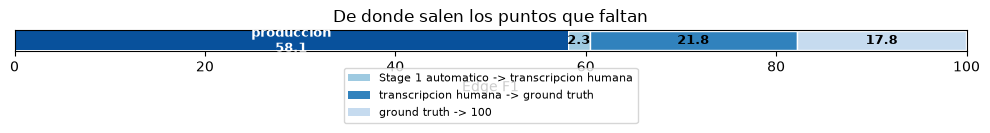

In [3]:
prod_e = res.loc["produccion", "Edge F1"]
vis_e  = res.loc["A · vision", "Edge F1"]
gt_e   = res.loc["B · oracle_gt", "Edge F1"]

tramos = pd.DataFrame([
    {"tramo": "Stage 1 automatico -> transcripcion humana",
     "puntos": vis_e - prod_e, "atribuible a": "calidad de lectura de la pizarra"},
    {"tramo": "transcripcion humana -> ground truth",
     "puntos": gt_e - vis_e,  "atribuible a": "informacion que NO esta en la pizarra"},
    {"tramo": "ground truth -> 100",
     "puntos": 100 - gt_e,    "atribuible a": "perdida propia de Stage 2 (con la respuesta en la mano)"},
]).set_index("tramo")
tramos["% de la brecha"] = 100 * tramos["puntos"] / (100 - prod_e)
display(tramos.round(2))

fig, ax = plt.subplots(figsize=(10, 2.3))
izq = prod_e
colores = ["#9ecae1", "#3182bd", "#c6dbef"]
for (nombre, fila), c in zip(tramos.iterrows(), colores):
    ax.barh([0], fila["puntos"], left=izq, color=c, edgecolor="white")
    if fila["puntos"] > 2:
        ax.text(izq + fila["puntos"] / 2, 0, f"{fila['puntos']:.1f}", ha="center",
                va="center", fontsize=9, fontweight="bold")
    izq += fila["puntos"]
ax.barh([0], prod_e, color="#08519c")
ax.text(prod_e / 2, 0, f"produccion\n{prod_e:.1f}", ha="center", va="center",
        color="white", fontweight="bold", fontsize=9)
ax.set_xlim(0, 100); ax.set_yticks([]); ax.set_xlabel("Edge F1")
ax.set_title("De donde salen los puntos que faltan")
ax.legend([plt.Rectangle((0,0),1,1,fc=c) for c in colores],
          list(tramos.index), loc="upper center", bbox_to_anchor=(.5,-.55), fontsize=8)
plt.tight_layout(); plt.show()

El tramo más grande con diferencia es el del medio: **información que la pizarra no tiene**.
El primer tramo —lo único que un Stage 1 mejor podría recuperar— es el más chico de los
tres, y ni siquiera supera el MDE.

## 4 · Prueba pareada por video

Los promedios pueden esconder un brazo que gana en pocos videos por mucho. Se comparan
video a video con prueba de signos exacta, contra la réplica de producción más reciente.

In [4]:
def test_signos(g: int, p: int) -> float:
    n = g + p
    if n == 0:
        return 1.0
    k = min(g, p)
    return min(1.0, 2 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n)

REF = BRAZOS["produccion"][-1]          # replica mas reciente de produccion

comparaciones = []
for b in ["A · vision", "B · oracle_gt"]:
    otro = BRAZOS[b][0]
    vids = sorted(set(REF["por_video"]) & set(otro["por_video"]))
    for metrica, clave in (("Edge F1", "edge_f1"), ("Service F1", "svc_f1")):
        g = p = e = 0
        difs = []
        for v in vids:
            x = 100 * otro["por_video"][v][clave]
            y = 100 * REF["por_video"][v][clave]
            difs.append(x - y)
            if abs(x - y) < 1e-9: e += 1
            elif x > y:           g += 1
            else:                 p += 1
        comparaciones.append({
            "brazo": b, "metrica": metrica, "n": len(vids),
            "gana": g, "pierde": p, "empata": e,
            "dif media": np.mean(difs), "p (signos)": test_signos(g, p),
        })

comp = pd.DataFrame(comparaciones)
comp["veredicto"] = np.where(comp["p (signos)"] < 0.05, "significativo", "no significativo")
display(comp.set_index(["brazo", "metrica"]).round(4))
print(f"\nreferencia de produccion: {REF['corrida']}")

n  gana  pierde  empata  dif media  p (signos)         veredicto
brazo         metrica                                                                      
A · vision    Edge F1     30    17       7       6     2.5279      0.0639  no significativo
              Service F1  30    11       8      11     1.6875      0.6476  no significativo
B · oracle_gt Edge F1     30    27       1       2    25.3154      0.0000     significativo
              Service F1  30    26       0       4    13.5692      0.0000     significativo


referencia de produccion: 2026-08-29_0715_STAGE2_V6_CORRECTED_cell9_p30_rep4


El brazo B gana en prácticamente todos los videos y da un p minúsculo. El brazo A reparte
victorias y derrotas de forma compatible con el azar — el mismo veredicto que dio la
comparación de medias contra el MDE, ahora por una vía independiente que no usa el piso de
ruido.

## 5 · ¿Y el Service F1?

Vale mirarlo aparte porque cuenta una historia distinta y refuerza el argumento.

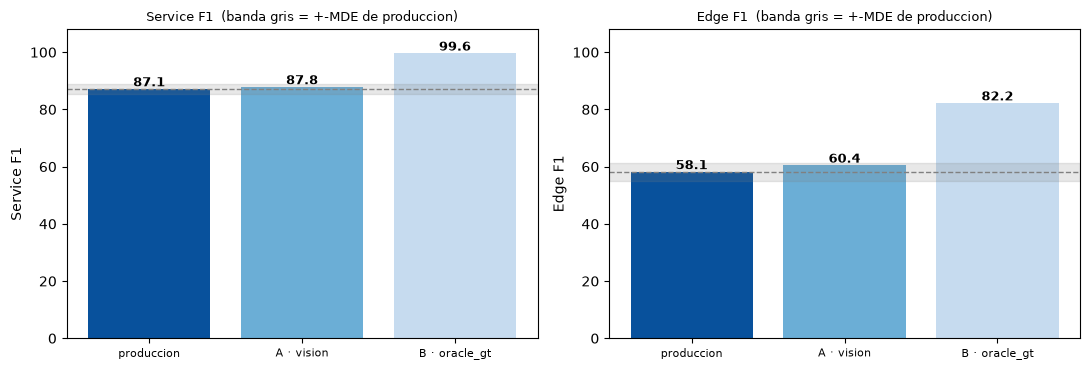

Service F1 — brazo A vs produccion: +0.72 pts (0.41x MDE)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, metrica in zip(axes, ["Service F1", "Edge F1"]):
    vals = res[metrica]
    barras = ax.bar(range(len(vals)), vals, color=["#08519c", "#6baed6", "#c6dbef"])
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(vals.index, fontsize=8)
    base_v = vals["produccion"]
    ax.axhline(base_v, ls="--", c="gray", lw=1)
    ax.axhspan(base_v - MDE[metrica], base_v + MDE[metrica], color="gray", alpha=.18)
    for i, v in enumerate(vals):
        ax.text(i, v + 1, f"{v:.1f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_ylim(0, 108); ax.set_ylabel(metrica)
    ax.set_title(f"{metrica}  (banda gris = +-MDE de produccion)", fontsize=9)
plt.tight_layout(); plt.show()

print("Service F1 — brazo A vs produccion: "
      f"{res.loc['A · vision','Service F1'] - res.loc['produccion','Service F1']:+.2f} pts "
      f"({abs(res.loc['A · vision','Service F1'] - res.loc['produccion','Service F1'])/MDE['Service F1']:.2f}x MDE)")

En **Service F1** el brazo A tampoco se despega: identificar *qué servicios* hay es algo
que el pipeline automático ya hace casi tan bien como un humano mirando la misma imagen.
Los íconos de AWS son legibles; el problema nunca estuvo ahí.

El oráculo GT llega a ~99.6 y no a 100 porque Stage 2, incluso recibiendo la lista
correcta, todavía funde o renombra algún nodo.

## 6 · Lo que este notebook autoriza a afirmar

1. **Stage 2 no es el cuello de botella.** Con la entrada correcta pasa de ~58 a ~82 de
   Edge F1 (más de 7× el MDE).
2. **Stage 1 tampoco lo es, al menos no por calidad de lectura.** Reemplazarlo por un
   humano leyendo la misma pizarra no produce una diferencia detectable.
3. **El límite es la fuente.** La pizarra no contiene la topología completa que el ground
   truth registra; falta el canal verbal.
4. **El oráculo GT no es un techo alcanzable**, es un diagnóstico: mide cuánto se pierde en
   la traducción cuando la información sí está.

### Amenazas a la validez, para declarar en el paper

- **Una sola corrida del brazo A** (contra 4 y 2 de los otros). Afirmamos "no distinguible
  del ruido", que es más débil que "igual", y necesita una réplica.
- El anotador humano del brazo A **conocía el esquema de Cloudscape**, aunque no el GT de
  cada video. Vio la pizarra, no el video ni el audio.
- El brazo A hereda las convenciones de anotación; una convención distinta mueve el número
  (documentado en el cuaderno de anotación).

In [6]:
OUT = Path("../reports/rq3_oraculos.json")
payload = {
    "generado_por": "notebooks/06_rq3_oraculos.ipynb",
    "prompt_sha": PROD_SHA,
    "panel": 30,
    "mde_n30": MDE,
    "brazos": {b: {"corridas": [c["corrida"] for c in cs],
                   "service_f1_mean": round(float(res.loc[b, "Service F1"]), 2),
                   "edge_f1_mean": round(float(res.loc[b, "Edge F1"]), 2)}
               for b, cs in BRAZOS.items()},
    "descomposicion_brecha_edge": tramos.round(2).reset_index().to_dict(orient="records"),
    "pruebas_pareadas": comp.round(6).to_dict(orient="records"),
    "conclusion": "El brazo de vision humana NO se despega de produccion (dentro del MDE). "
                  "El cuello de botella no es la fidelidad de lectura de la pizarra sino la "
                  "informacion ausente en ella; el canal verbal es imprescindible.",
}
OUT.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"escrito -> {OUT}")

escrito -> ../reports/rq3_oraculos.json
